In [1]:
import numpy as np # Math
import pandas as pd # Data tables
import matplotlib.pyplot as plt # Plots
import sklearn # Classic ML

Best Pruning Alpha: 0.00000
Leaves: 142, Depth: 14
Test Accuracy: 0.825
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78        36
           2       0.78      0.80      0.79        35
           3       0.79      0.81      0.80        37
           4       0.86      0.86      0.86        36
           5       0.88      0.95      0.91        37
           6       0.81      0.83      0.82        36
           7       0.84      0.86      0.85        36
           8       0.71      0.69      0.70        35
           9       0.82      0.75      0.78        36

    accuracy                           0.82       360
   macro avg       0.82      0.82      0.82       360
weighted avg       0.82      0.82      0.82       360

Confusion Matrix:


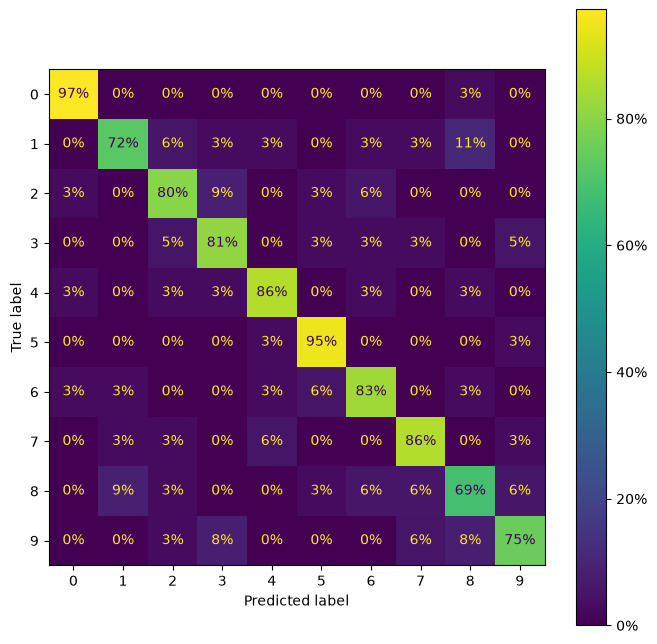

In [2]:
# Scikit-learn: Classification Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from matplotlib.ticker import PercentFormatter

dataset = load_digits(as_frame=True).frame # turn data (handwritten digits) into pandas dataframe
X = dataset.drop(columns = "target")
y = dataset["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #keep proportion of target differentiators in the sub-datasets
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train,y_train) # goal: find signficant alpha values
hyperparameter_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                         cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
                         param_grid={"ccp_alpha": path.ccp_alphas[:-1]}, # prune based on leaf number; find beset pruning coefficient
                         scoring="accuracy", # all errors weighed equally bad
                         n_jobs=-1).fit(X_train,y_train)

CT_model = hyperparameter_search.best_estimator_

print(f"Best Pruning Alpha: {CT_model.ccp_alpha:.5f}") # best alpha param
print(f"Leaves: {CT_model.get_n_leaves()}, Depth: {CT_model.get_depth()}")
print(f"Test Accuracy: {CT_model.score(X_test,y_test)}")

print(f"Classification Report:\n{classification_report(y_test, CT_model.predict(X_test))}") # per-class breakdown instead of one global accuracy number
# precision - of everything the model called n, what fraction really was
# recall - of the real n's, what fraction did it classify correctly
# f1-score - harmonic mean of precision and recall
# support - how many true instances of n were in the test set

print("Confusion Matrix:")
fig, chart = plt.subplots(figsize=(8, 8)) # fig = 8x8 inch canvas; chart = the plot
display = ConfusionMatrixDisplay.from_estimator(CT_model, X_test, y_test, normalize="true", values_format=".0%", ax=chart) # diagonanl represents a correct prediction
# a 10x10 grid where rows are true labels and columns are predictions, value is how many true labels called prediction value
# cell (n,m) = how many real n's got called m's
display.im_.colorbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.show()
